# Factor Research Notebook

Pulls a short price history for a handful of tickers spanning the universe's four
sectors, computes all four factors, and reports the validation diagnostics
(Information Coefficient, IC decay, turnover) that decide whether a factor earns
weight in the composite signal. See `README.md` (Factor Methodology, Signal
Combination) for the full writeup.

News/sentiment coverage over this historical window will be empty (NewsAPI's free
tier only serves the last ~month of articles), so the sentiment factor is expected
to show up as all-NaN here. That's the expected, disclosed limitation described in
`README.md` under Limitations & Assumptions, not a bug.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt  # noqa: E402
import pandas as pd  # noqa: E402

from data.news import load_news  # noqa: E402
from data.prices import load_prices  # noqa: E402
from factors import mean_reversion, momentum, sentiment, volatility  # noqa: E402
from factors.composite import combine_factors  # noqa: E402
from factors.validation import ic_decay, information_coefficient, turnover  # noqa: E402

pd.set_option("display.precision", 4)

## Load data

A small cross-sector sample (not the full ~50-name universe) so this runs fast; swap in `config.universe.UNIVERSE` for the full research pass.

In [2]:
TICKERS = ["AAPL", "MSFT", "JNJ", "PFE", "JPM", "GS", "XOM", "CVX"]
START, END = "2022-01-01", "2024-01-01"

prices = load_prices(TICKERS, START, END, source="yfinance")
news = load_news(TICKERS, START, END, source="newsapi")

print(f"{len(prices)} price rows, {prices['date'].nunique()} trading days, {len(news)} headlines")
prices.head()

4008 price rows, 501 trading days, 0 headlines


,date,ticker,open,high,low,close,volume
0,2022-01-03,AAPL,173.8532,178.7903,173.7359,177.9397,104487900
1,2022-01-03,CVX,98.0507,99.9462,97.9421,99.5872,10717700
2,2022-01-03,GS,348.1217,357.3393,346.6361,353.7865,3334300
3,2022-01-03,JNJ,149.7322,150.9549,148.7557,150.9021,6012200
4,2022-01-03,JPM,141.9116,144.3794,141.6008,143.5450,13120900


## Compute factor scores

In [3]:
factor_scores = {
    momentum.name: momentum.compute(prices),
    mean_reversion.name: mean_reversion.compute(prices),
    volatility.name: volatility.compute(prices),
    sentiment.name: sentiment.compute(prices, news),
}

for name, scores in factor_scores.items():
    coverage = scores["score"].notna().mean()
    print(f"{name:15s} non-NaN coverage: {coverage:.1%}")

momentum        non-NaN coverage: 49.7%
mean_reversion  non-NaN coverage: 95.2%
volatility      non-NaN coverage: 96.0%
sentiment       non-NaN coverage: 0.0%


## Factor validation: IC, IC decay, turnover

IC is the daily rank correlation between a factor's score and forward returns; IC decay shows how quickly that predictive power fades across horizons; turnover shows how often the top-decile membership changes (a proxy for the transaction costs of actually trading the signal).

In [4]:
summary_rows = []
decay_by_factor = {}

for name, scores in factor_scores.items():
    valid_scores = scores.dropna(subset=["score"])
    if valid_scores.empty:
        summary_rows.append(
            {"factor": name, "mean_ic_5d": float("nan"), "mean_turnover": float("nan")}
        )
        continue

    ic_series = information_coefficient(valid_scores, prices, horizon=5)
    decay = ic_decay(valid_scores, prices, horizons=(1, 5, 10, 21))
    decay_by_factor[name] = decay
    churn = turnover(valid_scores, top_frac=0.25)

    summary_rows.append(
        {
            "factor": name,
            "mean_ic_5d": ic_series.mean(),
            "mean_turnover": churn.mean(),
        }
    )

summary = pd.DataFrame(summary_rows).set_index("factor")
summary

,mean_ic_5d,mean_turnover
factor,,
momentum,0.0317,0.0504
mean_reversion,-0.0301,0.3372
volatility,-0.0510,0.0208
sentiment,NaN,NaN


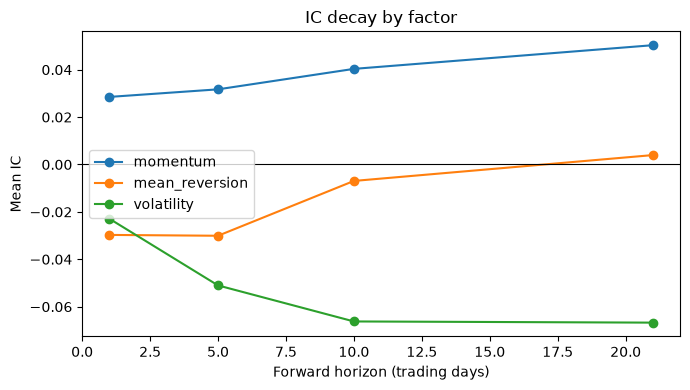

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
for name, decay in decay_by_factor.items():
    ax.plot(decay.index, decay.values, marker="o", label=name)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Forward horizon (trading days)")
ax.set_ylabel("Mean IC")
ax.set_title("IC decay by factor")
ax.legend()
plt.tight_layout()
plt.show()

## Composite signal

Trailing-IC-weighted blend (see `factors/composite.py`).

In [6]:
composite = combine_factors(factor_scores, prices)
composite_ic = information_coefficient(
    composite.rename(columns={"composite_score": "score"}), prices, horizon=5
)

print(f"Composite mean 5-day IC: {composite_ic.mean():.4f} over {len(composite_ic)} scored days")
composite.dropna(subset=["composite_score"]).tail()

Composite mean 5-day IC: -0.0058 over 476 scored days


,date,ticker,composite_score,rank
4003,2023-12-29,JNJ,-0.1310,4.0
4004,2023-12-29,JPM,0.4847,3.0
4005,2023-12-29,MSFT,1.2739,1.0
4006,2023-12-29,PFE,-1.3819,8.0
4007,2023-12-29,XOM,-0.2966,6.0
